In [3]:
import pandas as pd
from token_library import VOCAB, ALL_VALID_TOKENS, ALLOWED_PUNCTUATION
calls_df = pd.read_csv("../data/ford-catalogue/online_catalogue_annotated_parsed.csv")

## Preprocessing: Explode to unit-level (subpart) dataframe

In [4]:
def classify_tokens(unit_str):
    """
    Given a single unit string (e.g. "UP T SHORT FAST"), 
    classify each token into its vocabulary category.
    Returns a dict with keys: prr, contours, modifiers, specials, uncertain
    """
    result = {
        'prr': None,
        'contours': [],
        'modifiers': [],
        'specials': [],
        'uncertain': False,
        'is_transition': False
    }
    
    raw_tokens = unit_str.strip().split()
    for token in raw_tokens:
        t = token.upper().strip()
        
        # Handle punctuation
        if t in ALLOWED_PUNCTUATION:
            if t == '?':
                result['uncertain'] = True
            # '|' is an "or" — we keep it in raw but skip classification
            continue
        
        # Strip trailing ?
        if t.endswith('?'):
            result['uncertain'] = True
            t = t.rstrip('?')
        
        if not t:
            continue
        
        # Classify
        if t in VOCAB['prr']:
            result['prr'] = t
        elif t in VOCAB['contour']:
            result['contours'].append(t)
        elif t in VOCAB['modifier']:
            result['modifiers'].append(t)
        elif t in VOCAB['special']:
            result['specials'].append(t)

    if 'T' in result['specials']:
        result['is_transition'] = True

    # Implicit NORMAL: if no PRR token and not a GAP
    if result['prr'] is None and 'GAP' not in result['specials']:
        result['prr'] = 'NORMAL'

    return result

res = classify_tokens("UP T SHORT FAST")
res


{'prr': 'NORMAL',
 'contours': ['UP'],
 'modifiers': ['SHORT', 'FAST'],
 'specials': ['T'],
 'uncertain': False,
 'is_transition': True}

In [5]:

def explode_to_units(df):
    """
    Explode the call-level dataframe into a unit-level (subpart) dataframe.
    Each row = one comma-separated unit within a part.
    """
    rows = []
    
    part_cols = [f'P{i}' for i in range(1, 6)] + ['BIPHO', 'EXTRA']
    
    for idx in df[df['Annotated'] == True].index:
        row = df.loc[idx]
        call_unit_counter = 0  # sequential counter across parts within a call
        
        for part in part_cols:
            content = row.get(part)
            if pd.isna(content) or not content:
                continue
            
            part_start = row.get(f'{part}_start')
            part_end = row.get(f'{part}_end')
            part_duration = None
            if pd.notna(part_start) and pd.notna(part_end):
                part_duration = float(part_end) - float(part_start)
            
            # First split by | to get alternatives (each redefines all units)
            alternatives = [a.strip() for a in str(content).split('|')]
            
            # Max units across alternatives — next part starts after this
            max_units_in_part = max(
                len([u for u in alt.split(',') if u.strip()])
                for alt in alternatives
            )
            
            for alt_idx, alt_str in enumerate(alternatives):
                # Then split by , to get units within this alternative
                units = [u.strip() for u in alt_str.split(',')]
                n_units = len(units)
                
                for unit_idx, unit_str in enumerate(units):
                    if not unit_str:
                        continue
                    
                    classified = classify_tokens(unit_str)
                    
                    unit_row = {
                        # Call-level info
                        'filename': row['filename'],
                        'call_type': row['call_type'],
                        'call_number': row.get('call_number'),
                        'clan': row.get('clan'),
                        'pod': row.get('pod'),
                        
                        # Part-level info
                        'part': part,
                        'part_start': part_start,
                        'part_end': part_end,
                        'part_duration': part_duration,
                        'part_is_short': part_duration is not None and part_duration < 0.1,
                        'part_alternative': alt_idx,  # 0 = primary, 1+ = alternatives
                        
                        # Unit-level info
                        'part_unit_idx': unit_idx + 1,  # 1-based, position within part/alternative
                        'call_unit_idx': call_unit_counter + unit_idx + 1,  # 1-based, position across entire call
                        'n_units': n_units,
                        
                        'raw_unit': unit_str,
                        
                        # Classified tokens
                        'prr': classified['prr'],
                        'contours': ', '.join(classified['contours']) if classified['contours'] else None,
                        'modifiers': ', '.join(classified['modifiers']) if classified['modifiers'] else None,
                        'specials': ', '.join(classified['specials']) if classified['specials'] else None,
                        'uncertain': classified['uncertain'],
                        'is_transition': classified['is_transition'],
                        
                        # Also store as lists for easy filtering
                        'contour_list': classified['contours'],
                        'modifier_list': classified['modifiers'],
                        'special_list': classified['specials'],
                        
                        # Note from the call
                        'note': row.get('note'),
                    }
                    
                    # Implicit SHORT: if part duration < 0.1s, add SHORT to modifiers
                    if unit_row['part_is_short'] and 'SHORT' not in (classified['modifiers'] or []):
                        if classified['modifiers']:
                            unit_row['modifiers'] += ', SHORT'
                        else:
                            unit_row['modifiers'] = 'SHORT'
                        unit_row['modifier_list'] = unit_row['modifier_list'] + ['SHORT']
                    
                    rows.append(unit_row)
            
            # Advance call-level counter by max units across alternatives
            call_unit_counter += max_units_in_part
    
    units_df = pd.DataFrame(rows)
    
   
    return units_df


units_df = explode_to_units(calls_df)
print(f"Created units_df: {len(units_df)} unit rows from {units_df['filename'].nunique()} calls")
print(f"\nParts distribution:")
print(units_df['part'].value_counts().to_string())
print(f"\nPRR distribution (with implicit NORMAL):")
print(units_df['prr'].value_counts().to_string())

Created units_df: 112 unit rows from 24 calls

Parts distribution:
part
P1       33
P2       28
P3       24
BIPHO    21
P4        5
EXTRA     1

PRR distribution (with implicit NORMAL):
prr
NORMAL      68
TIGHT       19
BLUR        13
VERTICAL     6
SPACED       5


In [6]:
# Preview the units dataframe
display_cols = ['filename', 'part', 'part_alternative', 'part_unit_idx', 'call_unit_idx', 'n_units', 'raw_unit', 
                'prr', 'contours', 'modifiers', 'specials', 'uncertain',
                'part_duration', 'part_is_short']
units_df[display_cols]

,filename,part,part_alternative,part_unit_idx,call_unit_idx,n_units,raw_unit,prr,contours,modifiers,specials,uncertain,part_duration,part_is_short
0,N01i-A1-3,P1,0,1,1,1,BLUR,BLUR,None,None,None,False,0.195758,False
1,N01i-A1-3,P2,0,1,2,1,TIGHT FLAT ?,TIGHT,FLAT,None,None,True,0.122548,False
2,N01i-A1-3,P3,0,1,3,2,PEAK,NORMAL,PEAK,None,None,False,1.258900,False
3,N01i-A1-3,P3,0,2,4,2,FLAT,NORMAL,FLAT,None,None,False,1.258900,False
4,N01i-A1-3,BIPHO,0,1,5,3,UP,NORMAL,UP,None,None,False,1.343251,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,N27-A1-1,BIPHO,0,3,6,3,DOWN SHORT,NORMAL,DOWN,SHORT,None,False,0.289189,False
108,N47-A1-1,P1,0,1,1,1,BLUR,BLUR,None,None,None,False,0.197233,False
109,N47-A1-1,P2,0,1,2,1,UP SQUIGGLE,NORMAL,"UP, SQUIGGLE",None,None,False,0.599732,False
110,N47-A1-1,BIPHO,0,1,3,2,UP,NORMAL,UP,None,None,False,0.633335,False


In [7]:
units_df["is_transition"].value_counts()

is_transition
False    107
True       5
Name: count, dtype: int64

In [8]:
units_df[units_df["contour_list"].apply(lambda x: "SQUIGGLE" in x)]

,filename,call_type,call_number,clan,pod,part,part_start,part_end,part_duration,part_is_short,...,prr,contours,modifiers,specials,uncertain,is_transition,contour_list,modifier_list,special_list,note
23,N02-A4-1,N02,N02,A,A4,P2,0.530535,1.108886,0.578351,False,...,NORMAL,SQUIGGLE,None,None,False,False,[SQUIGGLE],[],[],NaN
109,N47-A1-1,N47,N47,A,A1,P2,0.374742,0.974474,0.599732,False,...,NORMAL,"UP, SQUIGGLE",None,None,False,False,"[UP, SQUIGGLE]",[],[],NaN
111,N47-A1-1,N47,N47,A,A1,BIPHO,0.341139,0.974474,0.633335,False,...,NORMAL,SQUIGGLE,None,None,False,False,[SQUIGGLE],[],[],NaN


## Analysis: Feature co-occurrence matrices

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mapping from vocab category name to the column(s) in units_df
# Token order is explicit: PRR from lowest to highest repetition rate
CATEGORY_COL_MAP = {
    'prr':      {'col': 'prr',           'is_list': False, 'tokens': ['VERTICAL', 'BLUR', 'TIGHT', 'NORMAL', 'SPACED']},
    'contour':  {'col': 'contour_list',   'is_list': True,  'tokens': sorted(VOCAB['contour'])},
    'modifier': {'col': 'modifier_list',  'is_list': True,  'tokens': sorted(VOCAB['modifier'])},
    'special':  {'col': 'special_list',   'is_list': True,  'tokens': sorted(VOCAB['special'])},
}


def build_cooccurrence_matrix(df, cat_row, cat_col, filter_part=None):
    """
    Build a co-occurrence count matrix between two vocabulary categories.
    
    Parameters
    ----------
    df : DataFrame
        The units_df dataframe.
    cat_row : str
        Vocabulary category for rows (e.g. 'prr', 'contour', 'modifier', 'special').
    cat_col : str
        Vocabulary category for columns.
    filter_part : str or list, optional
        Filter to specific parts (e.g. 'BIPHO', or ['P1','P2','P3']).
    
    Returns
    -------
    pd.DataFrame
        A count matrix (rows = cat_row tokens, cols = cat_col tokens).
    """
    row_info = CATEGORY_COL_MAP[cat_row]
    col_info = CATEGORY_COL_MAP[cat_col]
    
    sub = df.copy()
    if filter_part is not None:
        if isinstance(filter_part, str):
            filter_part = [filter_part]
        sub = sub[sub['part'].isin(filter_part)]
    
    row_tokens = row_info['tokens']
    col_tokens = col_info['tokens']
    
    matrix = pd.DataFrame(0, index=row_tokens, columns=col_tokens)
    
    for _, unit in sub.iterrows():
        # Get row values
        if row_info['is_list']:
            r_vals = unit[row_info['col']] if isinstance(unit[row_info['col']], list) else []
        else:
            r_vals = [unit[row_info['col']]] if pd.notna(unit[row_info['col']]) else []
        
        # Get col values
        if col_info['is_list']:
            c_vals = unit[col_info['col']] if isinstance(unit[col_info['col']], list) else []
        else:
            c_vals = [unit[col_info['col']]] if pd.notna(unit[col_info['col']]) else []
        
        for r in r_vals:
            for c in c_vals:
                if r in matrix.index and c in matrix.columns:
                    matrix.loc[r, c] += 1
    
    return matrix


def plot_cooccurrence(df, cat_row, cat_col, filter_part=None, normalize=None, 
                      figsize=(10, 6), cmap='YlOrRd', title=None):
    """
    Plot a heatmap of feature co-occurrence between two vocabulary categories.
    
    Parameters
    ----------
    df : DataFrame
        The units_df dataframe.
    cat_row : str
        Vocabulary category for rows (e.g. 'prr', 'contour', 'modifier', 'special').
    cat_col : str
        Vocabulary category for columns.
    filter_part : str or list, optional
        Filter to specific parts (e.g. 'BIPHO', or ['P1','P2','P3']).
    normalize : str, optional
        'row' to normalize each row to sum to 1, 'col' for columns, None for raw counts.
    figsize : tuple
        Figure size.
    cmap : str
        Colormap.
    title : str, optional
        Custom title. Auto-generated if None.
    """
    matrix = build_cooccurrence_matrix(df, cat_row, cat_col, filter_part)
    
    # Drop rows/cols that are all zeros
    matrix = matrix.loc[matrix.sum(axis=1) > 0, matrix.sum(axis=0) > 0]
    
    if matrix.empty:
        print("No co-occurrences found for this combination.")
        return
    
    # Store raw counts for annotation
    annot_matrix = matrix.copy()
    
    fmt = 'd'
    if normalize == 'row':
        matrix = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)
        fmt = '.1%'
    elif normalize == 'col':
        matrix = matrix.div(matrix.sum(axis=0), axis=1).fillna(0)
        fmt = '.1%'
    
    # Build title
    if title is None:
        part_label = f" (parts: {filter_part})" if filter_part else " (all parts)"
        norm_label = f", normalized by {normalize}" if normalize else ""
        title = f"{cat_row.upper()} × {cat_col.upper()}{part_label}{norm_label}"
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # For normalized: show heatmap colors from normalized values, but annotate with raw counts
    if normalize:
        sns.heatmap(matrix, annot=annot_matrix, fmt='d', cmap=cmap, 
                    linewidths=0.5, ax=ax, cbar_kws={'label': 'proportion'})
    else:
        sns.heatmap(matrix, annot=True, fmt=fmt, cmap=cmap, 
                    linewidths=0.5, ax=ax, cbar_kws={'label': 'count'})
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel(cat_row.upper(), fontsize=12)
    ax.set_xlabel(cat_col.upper(), fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return matrix

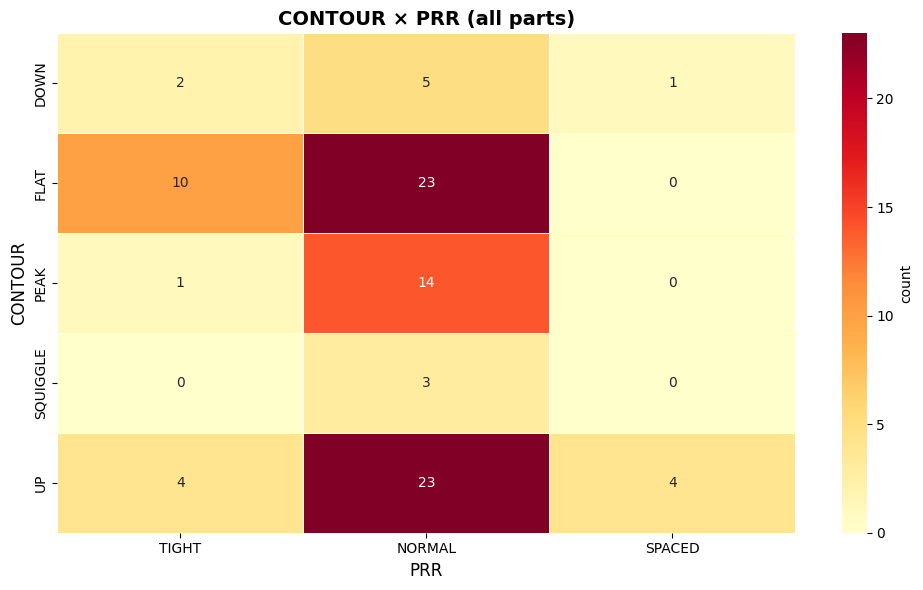

,TIGHT,NORMAL,SPACED
DOWN,2,5,1
FLAT,10,23,0
PEAK,1,14,0
SQUIGGLE,0,3,0
UP,4,23,4


In [10]:
# Contour × PRR — all parts
plot_cooccurrence(units_df, 'contour', 'prr')


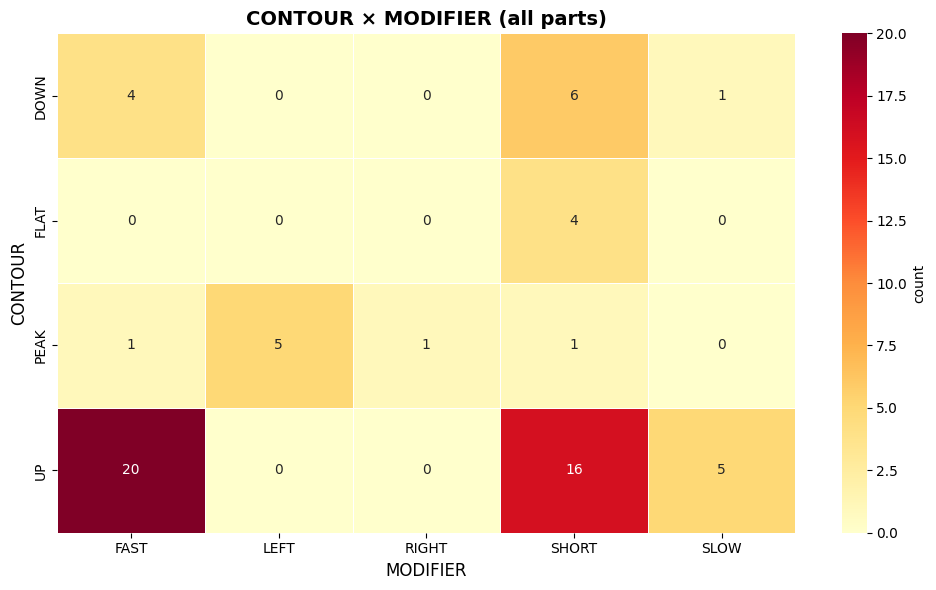

,FAST,LEFT,RIGHT,SHORT,SLOW
DOWN,4,0,0,6,1
FLAT,0,0,0,4,0
PEAK,1,5,1,1,0
UP,20,0,0,16,5


In [ ]:

plot_cooccurrence(units_df, 'contour', 'modifier')
# BIPHO only: Contour × PRR
# plot_cooccurrence(units_df, 'contour', 'prr', filter_part='BIPHO', 
#                   title='CONTOUR × PRR (BIPHO only)')

## Analysis: Transition probability matrix

In [ ]:
def _get_tokens(unit_row, cat_info):
    """Extract token list from a unit row for a given category."""
    if cat_info['is_list']:
        val = unit_row[cat_info['col']]
        return val if isinstance(val, list) else []
    else:
        val = unit_row[cat_info['col']]
        return [val] if pd.notna(val) else []


def build_transition_pairs(df, category, alt=0, exclude_transitions=False, 
                           between_parts_only=False, add_start_end=False):
    """
    Build a list of (current_token, next_token) pairs by following
    sequential call_unit_idx within each call.
    
    For list-based categories (contour, modifier), each token in the current
    unit is paired with each token in the next unit.
    
    Parameters
    ----------
    df : DataFrame
        The units_df dataframe.
    category : str
        Vocabulary category ('prr', 'contour', 'modifier', 'special').
    alt : int
        Which alternative to use (default 0 = primary).
    exclude_transitions : bool
        If True, filter out units where is_transition == True before 
        building pairs. The next available call_unit_idx is used.
    between_parts_only : bool
        If True, only create pairs between the last unit of one part and
        the first unit of the next part (no within-part transitions).
    add_start_end : bool
        If True, add START → first unit and last unit → END pseudo-transitions.
        When between_parts_only, uses the first unit of the first part and
        the last unit of the last part.
    
    Returns
    -------
    list of (str, str) tuples
    """
    cat_info = CATEGORY_COL_MAP[category]
    
    sub = df[df['part_alternative'] == alt].copy()
    
    if exclude_transitions and 'is_transition' in sub.columns:
        sub = sub[sub['is_transition'] == False]
    
    pairs = []
    
    for filename in sub['filename'].unique():
        call_units = sub[sub['filename'] == filename].sort_values('call_unit_idx')
        
        if call_units.empty:
            continue
        
        if between_parts_only:
            # Group by part, keeping the order of parts by their first call_unit_idx
            parts_in_order = (
                call_units.groupby('part')['call_unit_idx']
                .min()
                .sort_values()
                .index.tolist()
            )
            
            # START → first unit of first part
            if add_start_end and len(parts_in_order) > 0:
                first_part_units = call_units[call_units['part'] == parts_in_order[0]]
                first_unit = first_part_units.loc[first_part_units['call_unit_idx'].idxmin()]
                for t in _get_tokens(first_unit, cat_info):
                    pairs.append(('START', t))
            
            for i in range(len(parts_in_order) - 1):
                curr_part = parts_in_order[i]
                nxt_part = parts_in_order[i + 1]
                
                curr_part_units = call_units[call_units['part'] == curr_part]
                nxt_part_units = call_units[call_units['part'] == nxt_part]
                
                # Last unit of current part, first unit of next part
                last_unit = curr_part_units.loc[curr_part_units['call_unit_idx'].idxmax()]
                first_unit = nxt_part_units.loc[nxt_part_units['call_unit_idx'].idxmin()]
                
                for ct in _get_tokens(last_unit, cat_info):
                    for nt in _get_tokens(first_unit, cat_info):
                        pairs.append((ct, nt))
            
            # Last unit of last part → END
            if add_start_end and len(parts_in_order) > 0:
                last_part_units = call_units[call_units['part'] == parts_in_order[-1]]
                last_unit = last_part_units.loc[last_part_units['call_unit_idx'].idxmax()]
                for t in _get_tokens(last_unit, cat_info):
                    pairs.append((t, 'END'))
        else:
            # START → first unit
            if add_start_end:
                first = call_units.iloc[0]
                for t in _get_tokens(first, cat_info):
                    pairs.append(('START', t))
            
            for i in range(len(call_units) - 1):
                curr = call_units.iloc[i]
                nxt = call_units.iloc[i + 1]
                
                for ct in _get_tokens(curr, cat_info):
                    for nt in _get_tokens(nxt, cat_info):
                        pairs.append((ct, nt))
            
            # Last unit → END
            if add_start_end:
                last = call_units.iloc[-1]
                for t in _get_tokens(last, cat_info):
                    pairs.append((t, 'END'))
    
    return pairs


def plot_transition_matrix(df, category, alt=0, exclude_transitions=False,
                           between_parts_only=False, add_start_end=False,
                           normalize=True, figsize=(10, 8), cmap='YlOrRd', title=None):
    """
    Plot a transition probability matrix for a given vocabulary category.
    
    Shows P(next_token | current_token) as a heatmap.
    
    Parameters
    ----------
    df : DataFrame
        The units_df dataframe.
    category : str
        Vocabulary category ('prr', 'contour', 'modifier', 'special').
    alt : int
        Which alternative to use (default 0).
    exclude_transitions : bool
        If True, exclude transition units before computing.
    between_parts_only : bool
        If True, only transitions between parts (last unit of part → first of next).
    add_start_end : bool
        If True, add START and END pseudo-tokens to see how calls begin/end.
    normalize : bool
        If True, normalize rows to probabilities. If False, show raw counts.
    figsize : tuple
        Figure size.
    cmap : str
        Colormap.
    title : str, optional
        Custom title.
    """
    pairs = build_transition_pairs(df, category, alt=alt, 
                                   exclude_transitions=exclude_transitions,
                                   between_parts_only=between_parts_only,
                                   add_start_end=add_start_end)
    
    if not pairs:
        print("No transition pairs found.")
        return
    
    tokens = list(CATEGORY_COL_MAP[category]['tokens'])
    if add_start_end:
        tokens = ['START'] + tokens + ['END']
    
    # Build count matrix
    count_matrix = pd.DataFrame(0, index=tokens, columns=tokens)
    for curr, nxt in pairs:
        if curr in count_matrix.index and nxt in count_matrix.columns:
            count_matrix.loc[curr, nxt] += 1
    
    # Drop rows/cols that are all zeros
    active = count_matrix.sum(axis=1) + count_matrix.sum(axis=0)
    active_tokens = active[active > 0].index
    count_matrix = count_matrix.loc[active_tokens, active_tokens]
    
    if count_matrix.empty:
        print("No transitions found for this category.")
        return
    
    # Store raw counts for annotation
    annot_matrix = count_matrix.copy()
    
    if normalize:
        prob_matrix = count_matrix.div(count_matrix.sum(axis=1), axis=0).fillna(0)
        display_matrix = prob_matrix
    else:
        display_matrix = count_matrix
    
    # Title
    if title is None:
        flags = []
        if between_parts_only:
            flags.append("between parts only")
        if exclude_transitions:
            flags.append("excl. T units")
        if add_start_end:
            flags.append("with START/END")
        flag_str = f" ({', '.join(flags)})" if flags else ""
        norm_label = "probability" if normalize else "counts"
        title = f"Transition {norm_label}: {category.upper()}{flag_str}"
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Always use normalized values for colors; annotations show probabilities or raw counts
    prob_matrix = count_matrix.div(count_matrix.sum(axis=1), axis=0).fillna(0)
    
    if normalize:
        sns.heatmap(prob_matrix, annot=prob_matrix, fmt='.2f', cmap=cmap,
                    linewidths=0.5, ax=ax, vmin=0, vmax=1,
                    cbar_kws={'label': 'P(next | current)'})
    else:
        sns.heatmap(prob_matrix, annot=annot_matrix, fmt='d', cmap=cmap,
                    linewidths=0.5, ax=ax, vmin=0, vmax=1,
                    cbar_kws={'label': 'P(next | current)'})
    
    ax.set_ylabel('Current unit', fontsize=12)
    ax.set_xlabel('Next unit', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return display_matrix

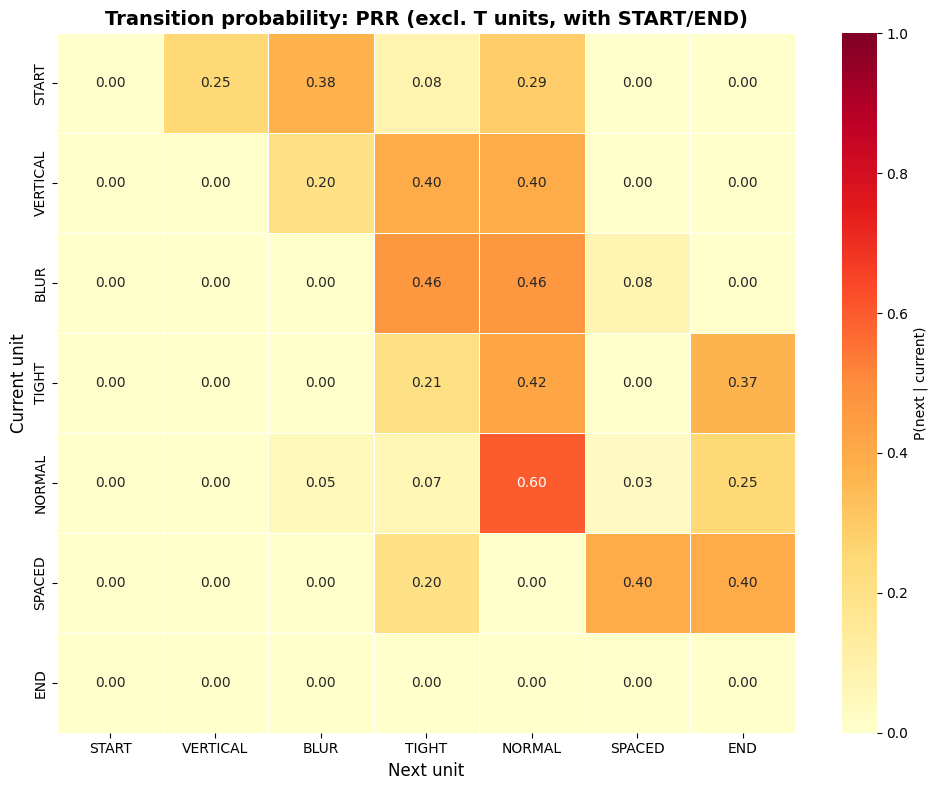

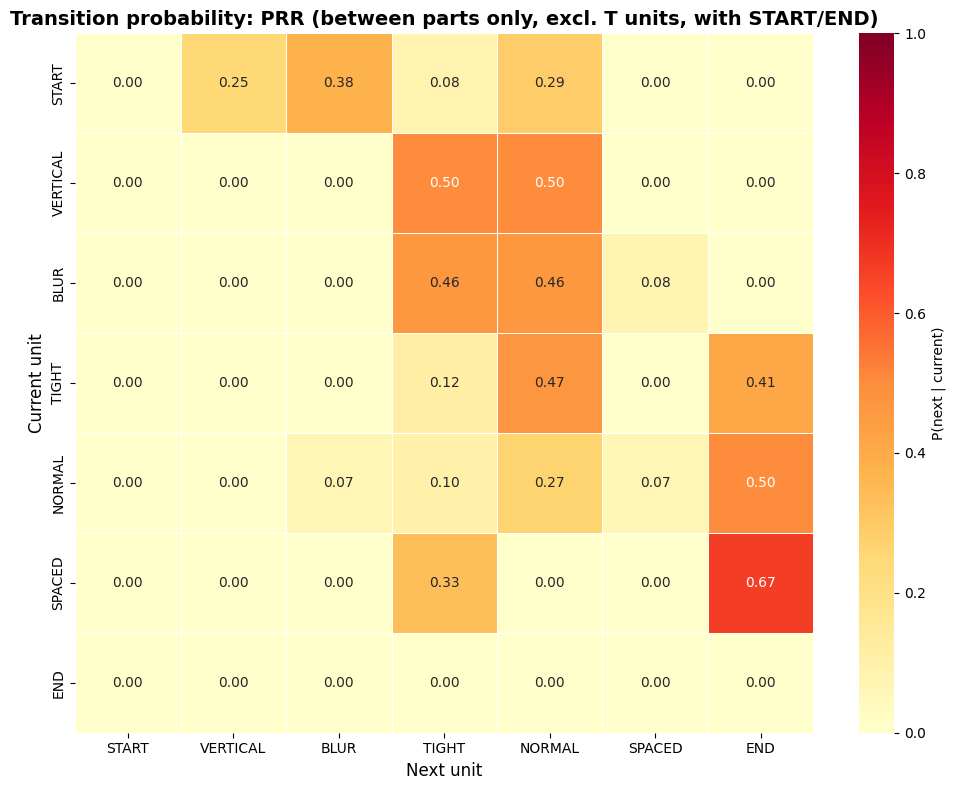

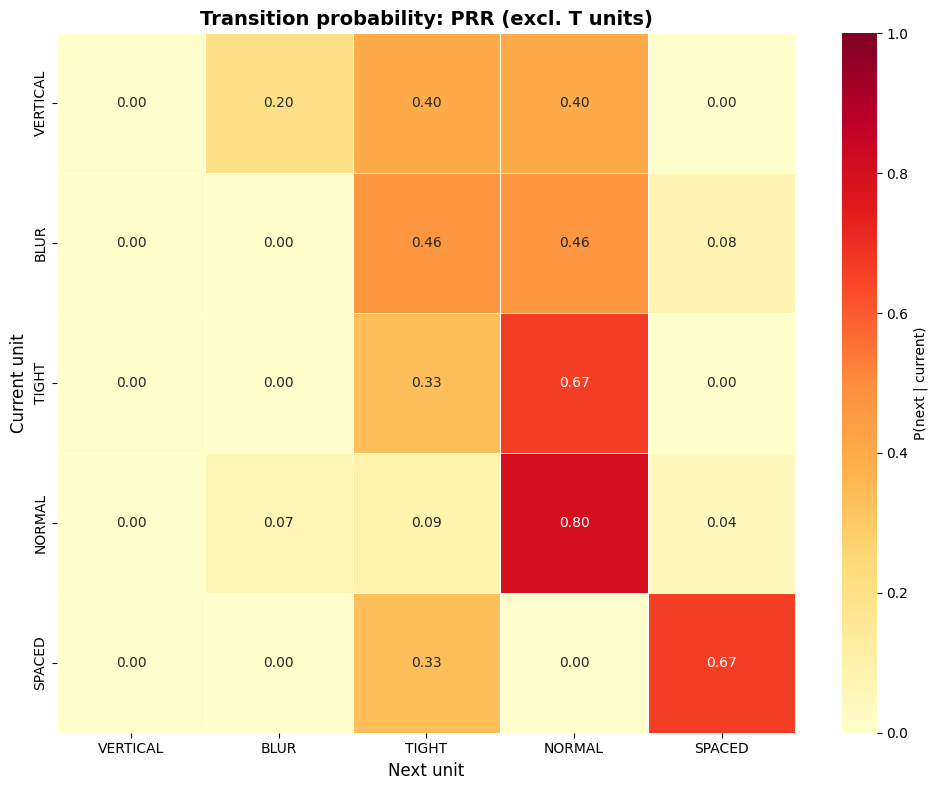

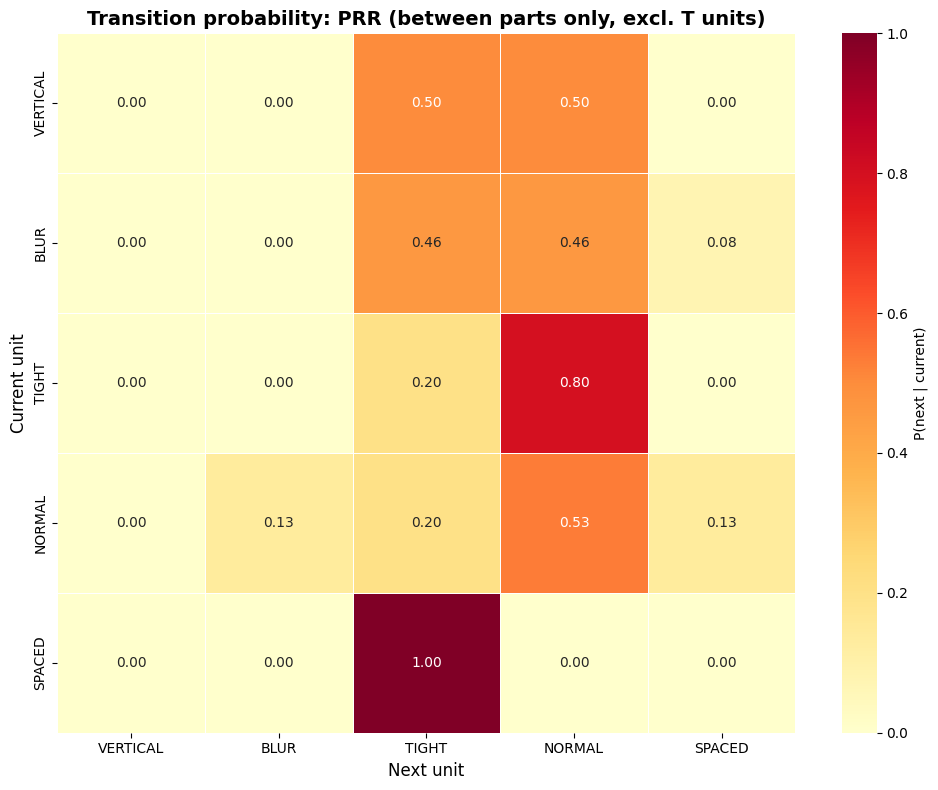

,VERTICAL,BLUR,TIGHT,NORMAL,SPACED
VERTICAL,0.0,0.000000,0.500000,0.500000,0.000000
BLUR,0.0,0.000000,0.461538,0.461538,0.076923
TIGHT,0.0,0.000000,0.200000,0.800000,0.000000
NORMAL,0.0,0.133333,0.200000,0.533333,0.133333
SPACED,0.0,0.000000,1.000000,0.000000,0.000000


In [ ]:
# All unit-to-unit contour transitions
# plot_transition_matrix(units_df, 'contour')

# # Only between-parts: last unit of part → first unit of next part
# plot_transition_matrix(units_df, 'contour', between_parts_only=False, exclude_transitions=True)

# # PRR transitions — all units
# plot_transition_matrix(units_df, 'prr')

# PRR transitions — between parts only
# plot_transition_matrix(units_df, 'prr', between_parts_only=True)

# Between parts, excluding T units
plot_transition_matrix(units_df, 'prr', exclude_transitions=True, add_start_end=True, normalize=True)
plot_transition_matrix(units_df, 'prr', exclude_transitions=True, add_start_end=True, between_parts_only=True, normalize=True)



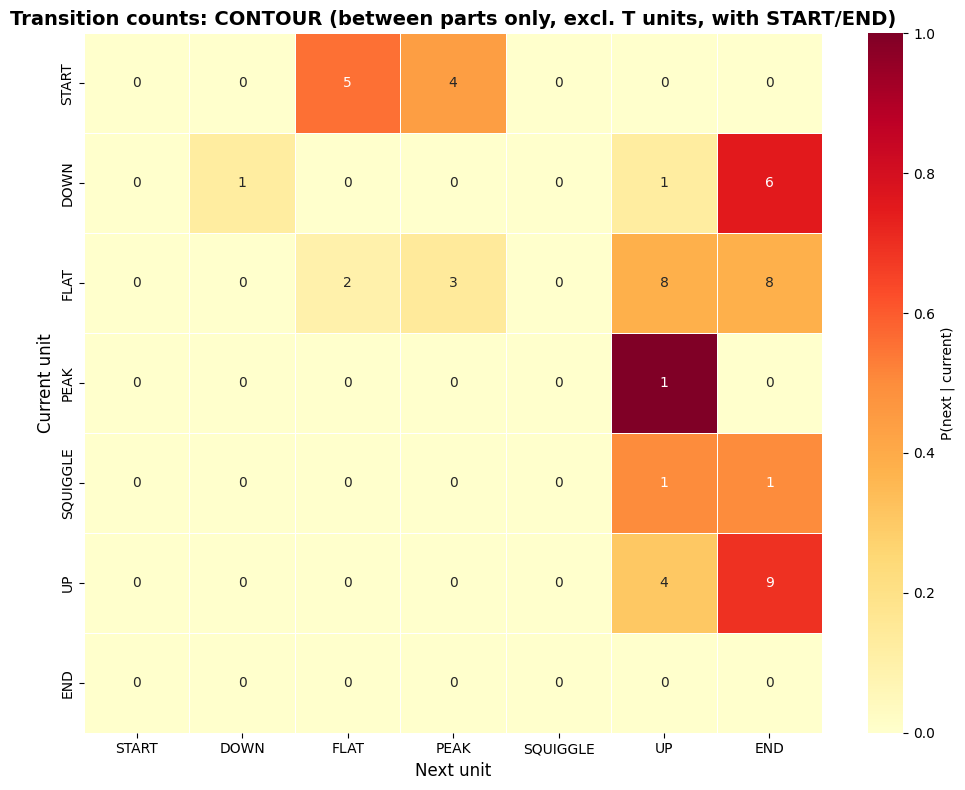

,START,DOWN,FLAT,PEAK,SQUIGGLE,UP,END
START,0,0,5,4,0,0,0
DOWN,0,1,0,0,0,1,6
FLAT,0,0,2,3,0,8,8
PEAK,0,0,0,0,0,1,0
SQUIGGLE,0,0,0,0,0,1,1
UP,0,0,0,0,0,4,9
END,0,0,0,0,0,0,0


In [ ]:

plot_transition_matrix(units_df, 'contour', exclude_transitions=True, add_start_end=True, between_parts_only=True, normalize=False)
